In [ ]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt

data_path = Path("array.pkl")
if not data_path.exists():
    data_path = Path("graphic/array.pkl")

with data_path.open("rb") as file:
    results = pickle.load(file)

results[:3]

[['en', 2, 100, 88.0, 0, 2.91],
 ['en', 2, 200, 97.333, 1, 5.54],
 ['en', 2, 350, 100.0, 3, 9.53],
 ['en', 3, 100, 78.333, 0, 3.22],
 ['en', 3, 200, 98.667, 2, 6.19],
 ['en', 3, 350, 100.0, 3, 10.77],
 ['en', 4, 100, 86.0, 2, 3.64],
 ['en', 4, 200, 100.0, 3, 6.95],
 ['en', 4, 350, 100.0, 3, 12.77]]

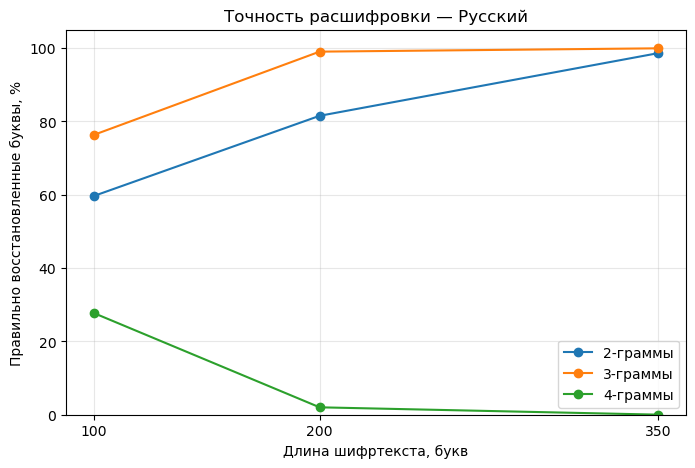

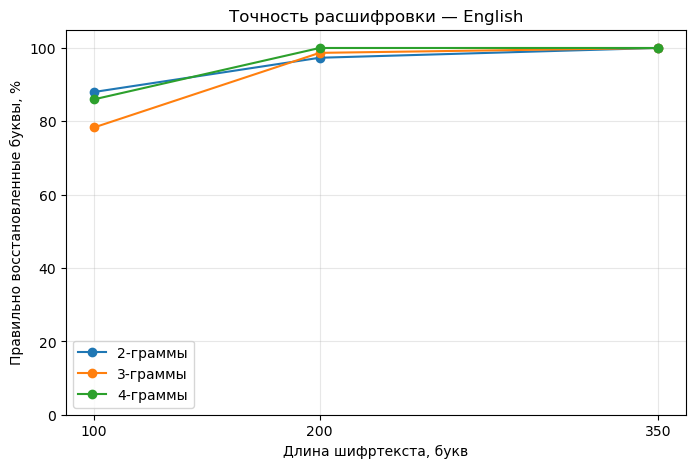

In [22]:
for language, title in (("ru", "Русский"), ("en", "English")):
    plt.figure(figsize=(8, 5))

    for n in (2, 3, 4):
        selected = [
            row for row in results
            if row[0] == language and row[1] == n
        ]

        lengths = [row[2] for row in selected]
        accuracies = [row[3] for row in selected]

        plt.plot(
            lengths,
            accuracies,
            marker="o",
            label=f"{n}-граммы",
        )

    plt.title(f"Точность расшифровки — {title}")
    plt.xlabel("Длина шифртекста, букв")
    plt.ylabel("Правильно восстановленные буквы, %")
    plt.xticks([100, 200, 350])
    plt.ylim(0, 105)
    plt.grid(alpha=0.3)
    plt.legend()

    plt.savefig(
        data_path.parent / f"accuracy_{language}.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()